# ***Projet : Diagnostic de la Maladie Rénale Chronique (CKD) – Classification & Clustering***
Membres:

Hafssa Archi
Imane Kouiri
Nada Souna
Kawtar EL-BAY


## Description du dataset

### **1. Contexte:**





La maladie rénale chronique (CKD) est une pathologie progressive qui affecte la fonction des reins et peut conduire à des complications graves si elle n’est pas détectée à temps. Le diagnostic précoce est crucial pour améliorer la prise en charge médicale et la qualité de vie des patients.

### **2. Objectifs:**

Le projet vise à développer un système d’analyse de données médicales capable de :

* Identifier des profils de patients
similaires via le clustering.

* Prédire si un patient est atteint de CKD grâce à la classification.

### **3. Description du Dataset:**

Le dataset utilisé est le Chronic Kidney Disease (CKD Dataset) disponible sur le UCI Machine Learning Repository. Il contient 24 variables cliniques et biologiques, mêlant données numériques et catégorielles.

Target (variable à prédire) :
* ckd → patient atteint de CKD
* notckd → patient sain

**Tableau de features:**

| Feature | Description        |
| ------- | ------------------ |
| age     | Âge du patient     |
| bp      | Pression sanguine  |
| sg      | Densité de l’urine |
| al      | Albumine           |
| su      | Sucre dans l’urine |
| rbc     | Globules rouges    |
| pc      | Cellules de pus    |
| ba      | Bactéries          |
| bgr     | Glucose sanguin    |
| bu      | Urée sanguine      |
| sc      | Créatinine         |
| sod     | Sodium             |
| pot     | Potassium          |
| hemo    | Hémoglobine        |
| pcv     | Volume globulaire  |
| wc      | Globules blancs    |
| rc      | Globules rouges    |
| htn     | Hypertension       |
| dm      | Diabète            |
| cad     | Maladie cardiaque  |
| appet   | Appétit            |
| pe      | Œdème              |
| ane     | Anémie             |


### **4. Méthodologie:**

**Étape 1 : Prétraitement des données**

* Gestion des valeurs manquantes
* Encodage des variables catégorielles
* Normalisation des données numériques

**Étape 2 : Clustering**

* Algorithmes utilisés : K-Means, Hierarchical Clustering, DBSCAN
* Identification du nombre optimal de clusters (méthode du coude, silhouette score)
* Analyse des profils de chaque cluster

**Étape 3 : Classification**

* Séparation du dataset en train/test
* Entraînement des modèles
* Évaluation et comparaison des performances

##Installation des datasets

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

# metadata
print(chronic_kidney_disease.metadata)

# variable information
print(chronic_kidney_disease.variables)


{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

##Importation des bibliotheques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

##EDA

###Distribution des variables + Histogrammes

In [ ]:
print("Shape of rows (patients):", X.shape)
print("Shape of columns (features):", y.shape)

Shape of rows (patients): (400, 24)
Shape of columns (features): (400, 1)


In [ ]:
import pandas as pd

df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [ ]:
print(df.describe())

              age          bp          sg          al          su         bgr  \
count  391.000000  388.000000  353.000000  354.000000  351.000000  356.000000   
mean    51.483376   76.469072    1.017408    1.016949    0.450142  148.036517   
std     17.169714   13.683637    0.005717    1.352679    1.099191   79.281714   
min      2.000000   50.000000    1.005000    0.000000    0.000000   22.000000   
25%     42.000000   70.000000    1.010000    0.000000    0.000000   99.000000   
50%     55.000000   80.000000    1.020000    0.000000    0.000000  121.000000   
75%     64.500000   80.000000    1.020000    2.000000    0.000000  163.000000   
max     90.000000  180.000000    1.025000    5.000000    5.000000  490.000000   

               bu          sc         sod         pot        hemo         pcv  \
count  381.000000  383.000000  313.000000  312.000000  348.000000  329.000000   
mean    57.425722    3.072454  137.528754    4.627244   12.526437   38.884498   
std     50.503006    5.7411

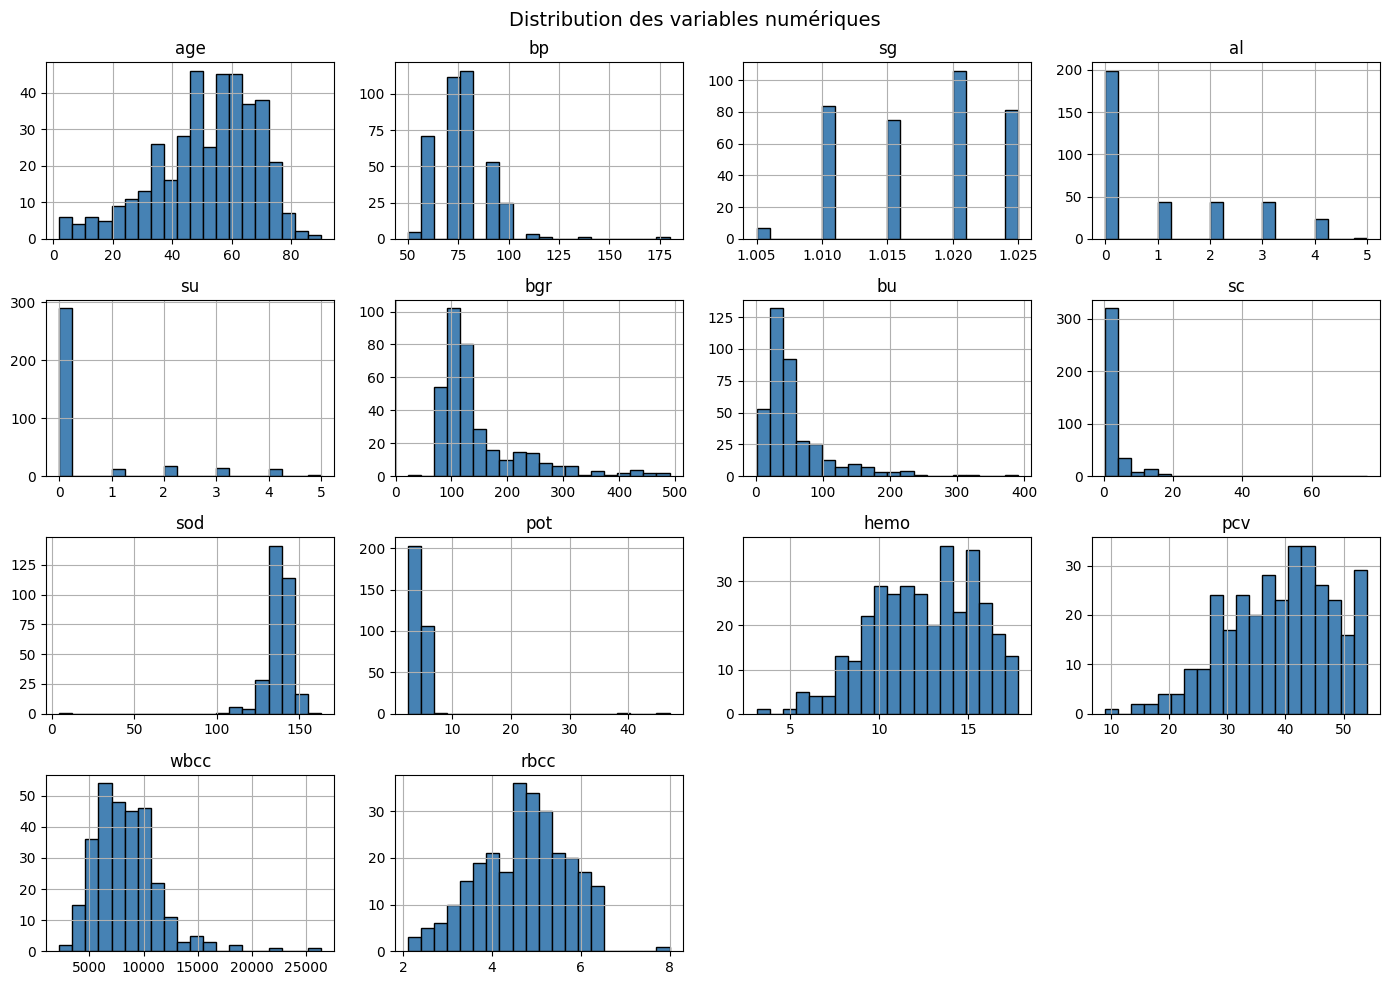

In [ ]:
#Histogramme pour chaque variable numerique
num_cols = df.select_dtypes(include='number').columns

df[num_cols].hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

###Corrélations + Heatmap

In [ ]:
# on garde seulement les colonnes numeriques pour la correlation
corr_matrix = df.select_dtypes(include='number').corr()

print("Matrice de corrélation :")
print(corr_matrix)

Matrice de corrélation :
           age        bp        sg        al        su       bgr        bu  \
age   1.000000  0.159480 -0.191096  0.122091  0.220866  0.244992  0.196985   
bp    0.159480  1.000000 -0.218836  0.160689  0.222576  0.160193  0.188517   
sg   -0.191096 -0.218836  1.000000 -0.469760 -0.296234 -0.374710 -0.314295   
al    0.122091  0.160689 -0.469760  1.000000  0.269305  0.379464  0.453528   
su    0.220866  0.222576 -0.296234  0.269305  1.000000  0.717827  0.168583   
bgr   0.244992  0.160193 -0.374710  0.379464  0.717827  1.000000  0.143322   
bu    0.196985  0.188517 -0.314295  0.453528  0.168583  0.143322  1.000000   
sc    0.132531  0.146222 -0.361473  0.399198  0.223244  0.114875  0.586368   
sod  -0.100046 -0.116422  0.412190 -0.459896 -0.131776 -0.267848 -0.323054   
pot   0.058377  0.075151 -0.072787  0.129038  0.219450  0.066966  0.357049   
hemo -0.192928 -0.306540  0.602582 -0.634632 -0.224775 -0.306189 -0.610360   
pcv  -0.242119 -0.326319  0.603560 -0.6

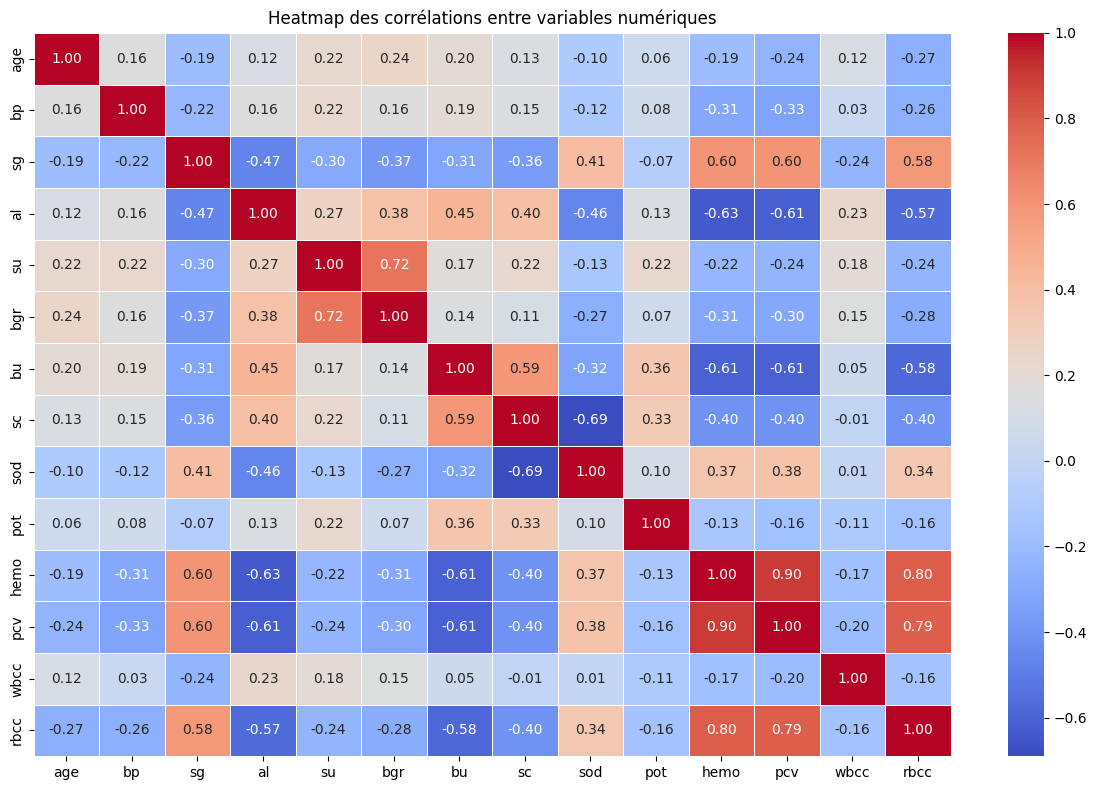

In [ ]:
# heatmap des correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap des corrélations entre variables numériques")
plt.tight_layout()
plt.show()

In [ ]:

from scipy import stats
print(" Bibliothèques importées")
print(f" DataFrame chargé: {df.shape}")

 Bibliothèques importées
 DataFrame chargé: (400, 25)


Relations entre variables et la maladie:

In [ ]:


print("="*60)
print(" STATISTIQUES COMPARATIVES CKD vs NON-CKD")
print("="*60)

# Identification des colonnes numériques (comme personne 1)
num_cols = df.select_dtypes(include='number').columns
print(f" Variables numériques analysées: {len(num_cols)}")

# DataFrame pour stocker les résultats
results = []

for col in num_cols:
    # Moyennes et écarts-types par groupe
    ckd_mean = df[df['class'] == 'ckd'][col].mean()
    ckd_std = df[df['class'] == 'ckd'][col].std()
    nonckd_mean = df[df['class'] == 'notckd'][col].mean()
    nonckd_std = df[df['class'] == 'notckd'][col].std()

    # Test t de Student
    ckd_vals = df[df['class'] == 'ckd'][col].dropna()
    nonckd_vals = df[df['class'] == 'notckd'][col].dropna()

    if len(ckd_vals) > 1 and len(nonckd_vals) > 1:
        t_stat, p_value = stats.ttest_ind(ckd_vals, nonckd_vals, nan_policy='omit')

        # Étoiles de significativité
        if p_value < 0.001:
            sig = '***'
        elif p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            sig = 'ns'

        results.append({
            'Variable': col,
            'CKD (moy±σ)': f"{ckd_mean:.2f} ± {ckd_std:.2f}",
            'Non-CKD (moy±σ)': f"{nonckd_mean:.2f} ± {nonckd_std:.2f}",
            'Différence': f"{ckd_mean - nonckd_mean:.2f}",
            'p-value': f"{p_value:.4f}",
            '': sig
        })

# Affichage
results_df = pd.DataFrame(results)
print("\n TABLEAU COMPARATIF:")
display(results_df)

 STATISTIQUES COMPARATIVES CKD vs NON-CKD
 Variables numériques analysées: 14

 TABLEAU COMPARATIF:


,Variable,CKD (moy±σ),Non-CKD (moy±σ),Différence,p-value,
0,age,54.42 ± 17.41,46.52 ± 15.63,7.91,0.0000,***
1,bp,79.71 ± 15.24,71.35 ± 8.54,8.35,0.0000,***
2,sg,1.01 ± 0.00,1.02 ± 0.00,-0.01,0.0000,***
3,al,1.72 ± 1.38,0.00 ± 0.00,1.72,0.0000,***
4,su,0.77 ± 1.35,0.00 ± 0.00,0.77,0.0000,***
5,bgr,175.52 ± 92.48,107.72 ± 18.56,67.80,0.0000,***
6,bu,72.66 ± 58.72,32.80 ± 11.45,39.86,0.0000,***
7,sc,4.43 ± 6.98,0.87 ± 0.26,3.56,0.0000,***
8,sod,133.88 ± 12.46,141.73 ± 4.82,-7.85,0.0000,***
9,pot,4.88 ± 4.35,4.34 ± 0.59,0.55,0.1353,ns


 GRAPHIQUE 1: BOXPLOTS COMPARATIFS


/tmp/ipykernel_13418/2370769898.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='class', y=col, ax=axes[i],
/tmp/ipykernel_13418/2370769898.py:14: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_box, x='class', y=col, ax=axes[i],
/tmp/ipykernel_13418/2370769898.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='class', y=col, ax=axes[i],
/tmp/ipykernel_13418/2370769898.py:14: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_box, x='class', y=col, ax=axes[

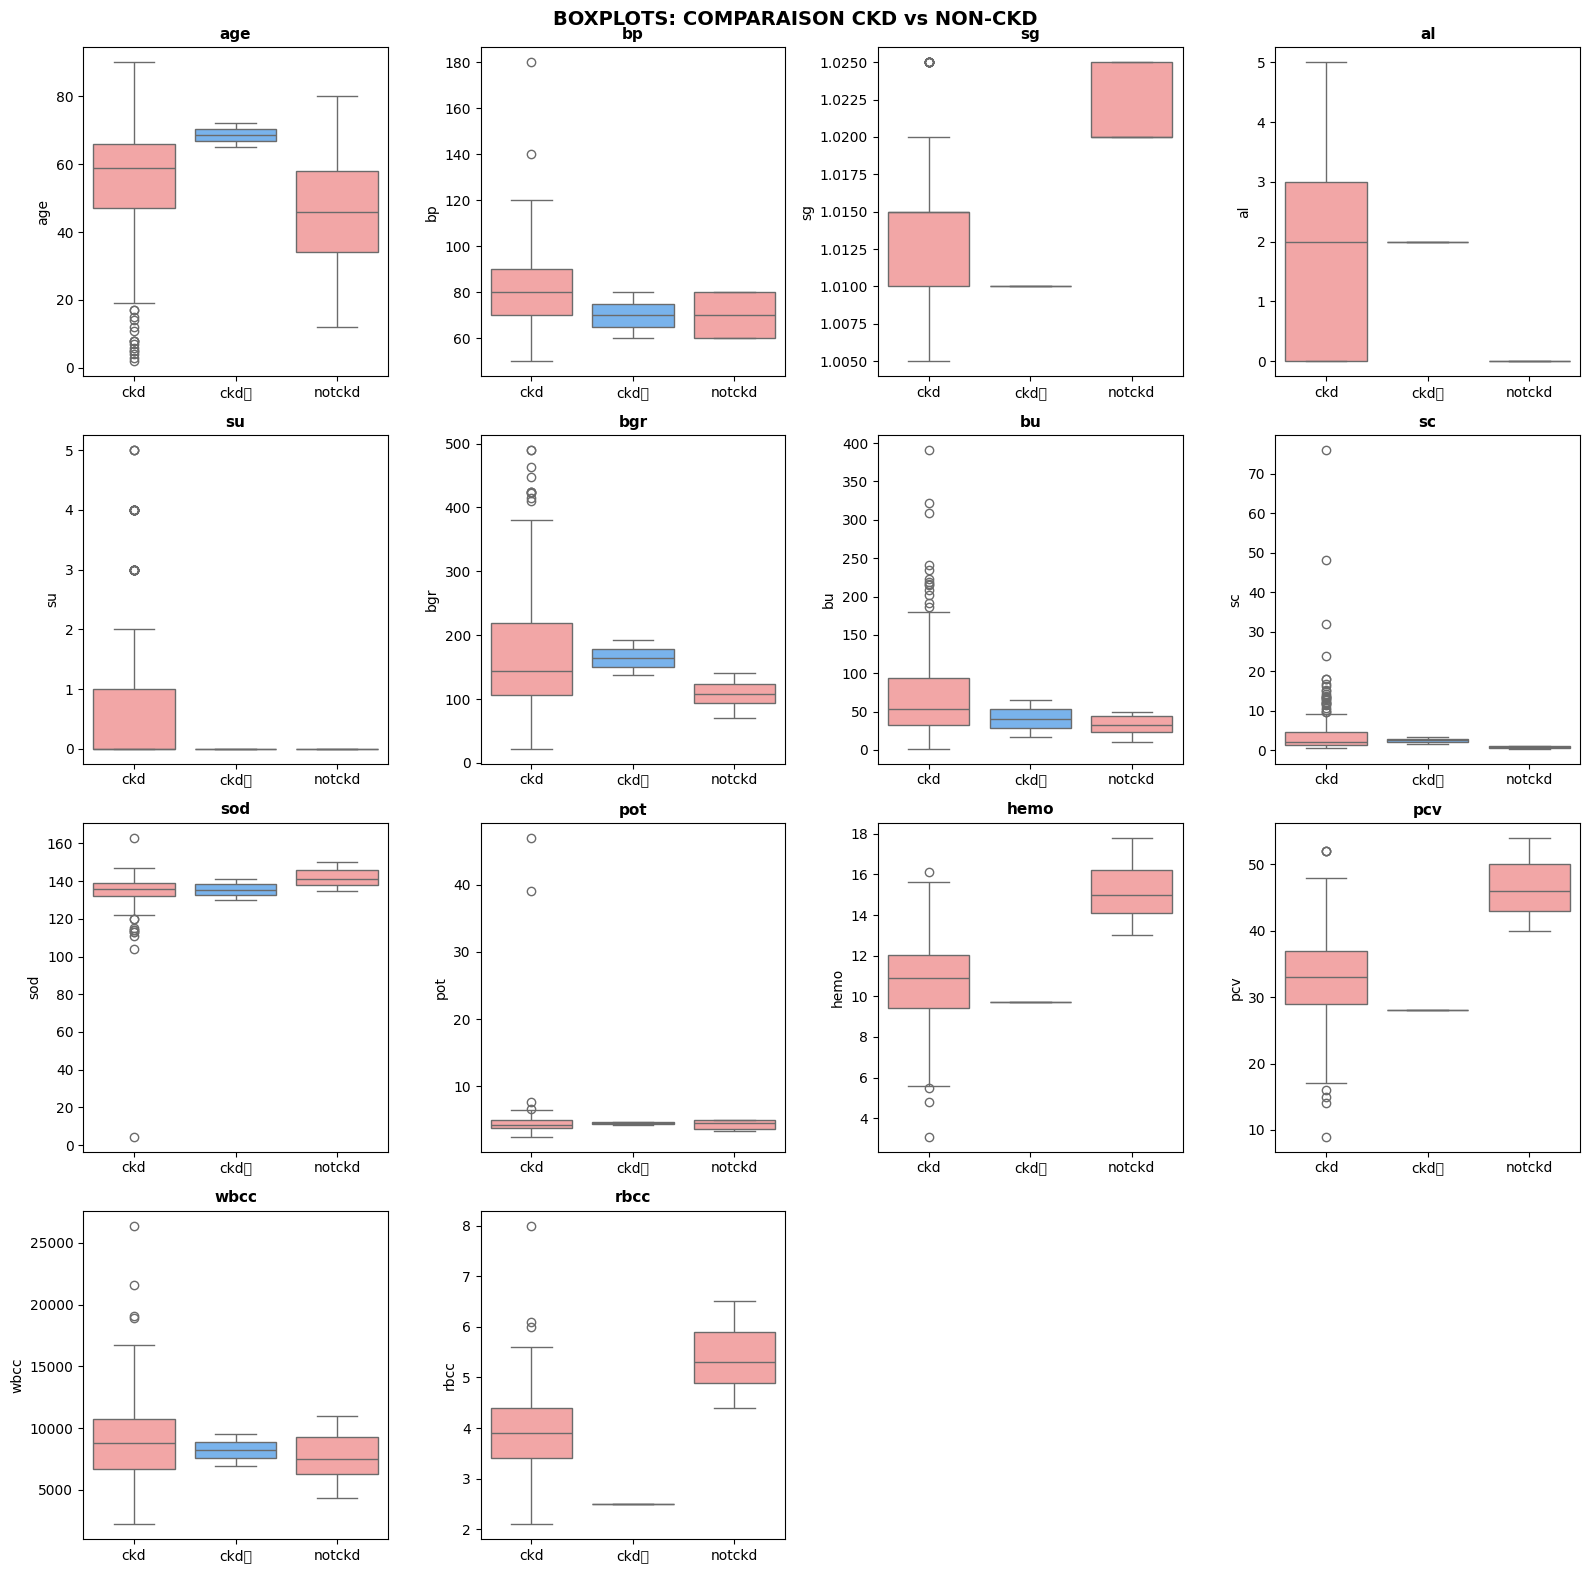

In [ ]:


print("="*60)
print(" GRAPHIQUE 1: BOXPLOTS COMPARATIFS")
print("="*60)

# Organisation des subplots
n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows*4))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    df_box = df[[col, 'class']].dropna()
    sns.boxplot(data=df_box, x='class', y=col, ax=axes[i],
                palette=['#ff9999', '#66b3ff'])
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')

# Cacher les sous-graphiques vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("BOXPLOTS: COMPARAISON CKD vs NON-CKD", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

GRAPHIQUE 2: VIOLIN PLOTS


/tmp/ipykernel_13418/236031619.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='class', y=col, ax=axes[i],
/tmp/ipykernel_13418/236031619.py:13: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=df_violin, x='class', y=col, ax=axes[i],
/tmp/ipykernel_13418/236031619.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='class', y=col, ax=axes[i],
/tmp/ipykernel_13418/236031619.py:13: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=df_violin, x='cla

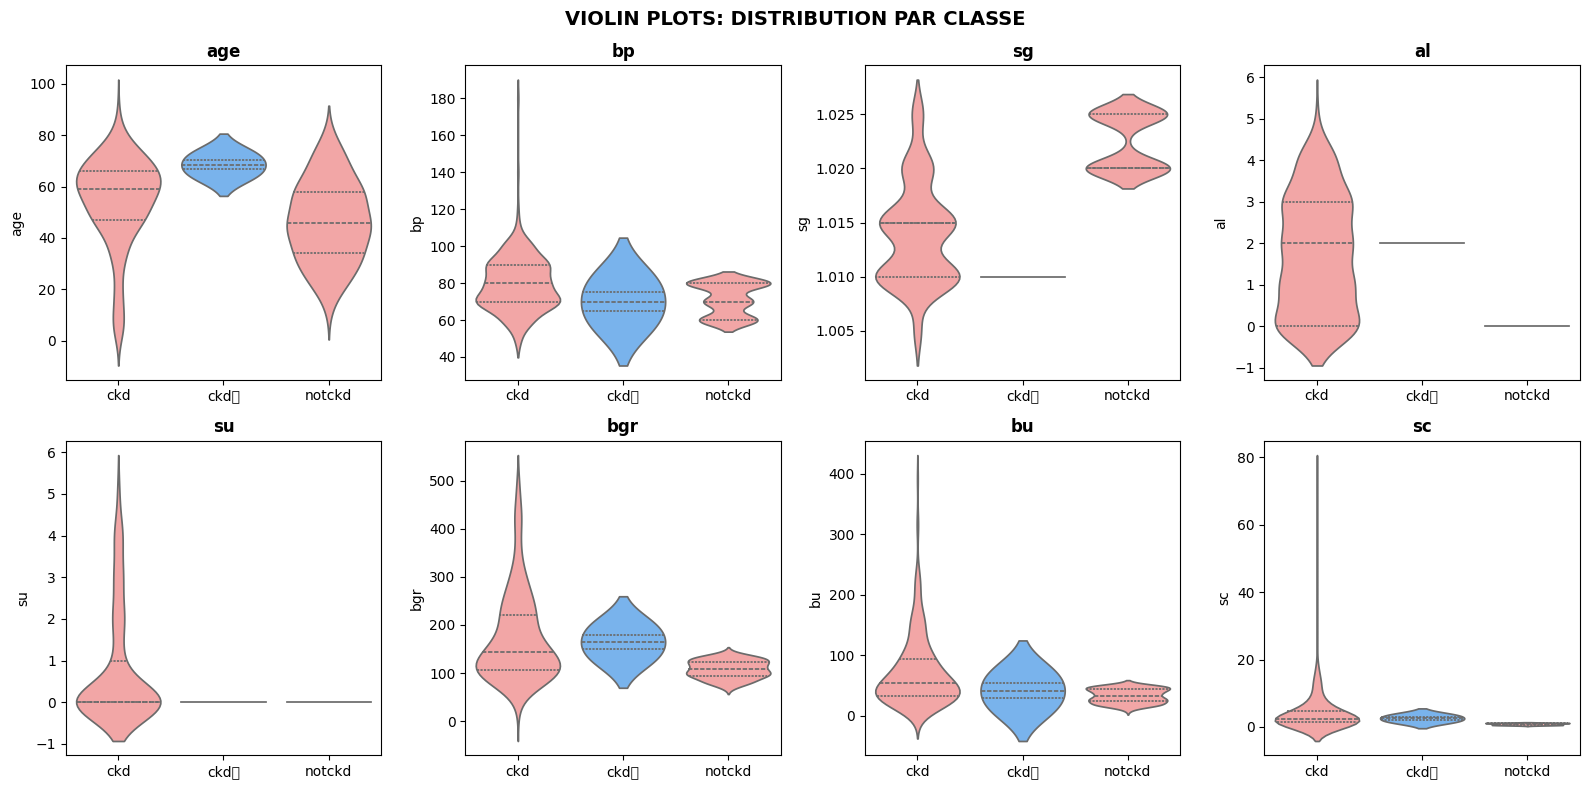

In [ ]:


print("="*60)
print("GRAPHIQUE 2: VIOLIN PLOTS")
print("="*60)

# Sélection des 8 premières variables
top_vars = num_cols[:8] if len(num_cols) >= 8 else num_cols

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(top_vars):
    df_violin = df[[col, 'class']].dropna()
    sns.violinplot(data=df_violin, x='class', y=col, ax=axes[i],
                   palette=['#ff9999', '#66b3ff'], inner='quartile')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')

# Cacher les vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("VIOLIN PLOTS: DISTRIBUTION PAR CLASSE", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Analyse des Outliers

Les outliers (valeurs aberrantes) sont des observations qui s’éloignent fortement du reste des données.  
Dans les données médicales, ils peuvent représenter :

- des erreurs de mesure
- des anomalies biologiques importantes
- des cas extrêmes de patients

Dans cette section, nous allons :

* visualiser les outliers avec des **boxplots**
* détecter les valeurs aberrantes avec la **méthode IQR (Interquartile Range)**

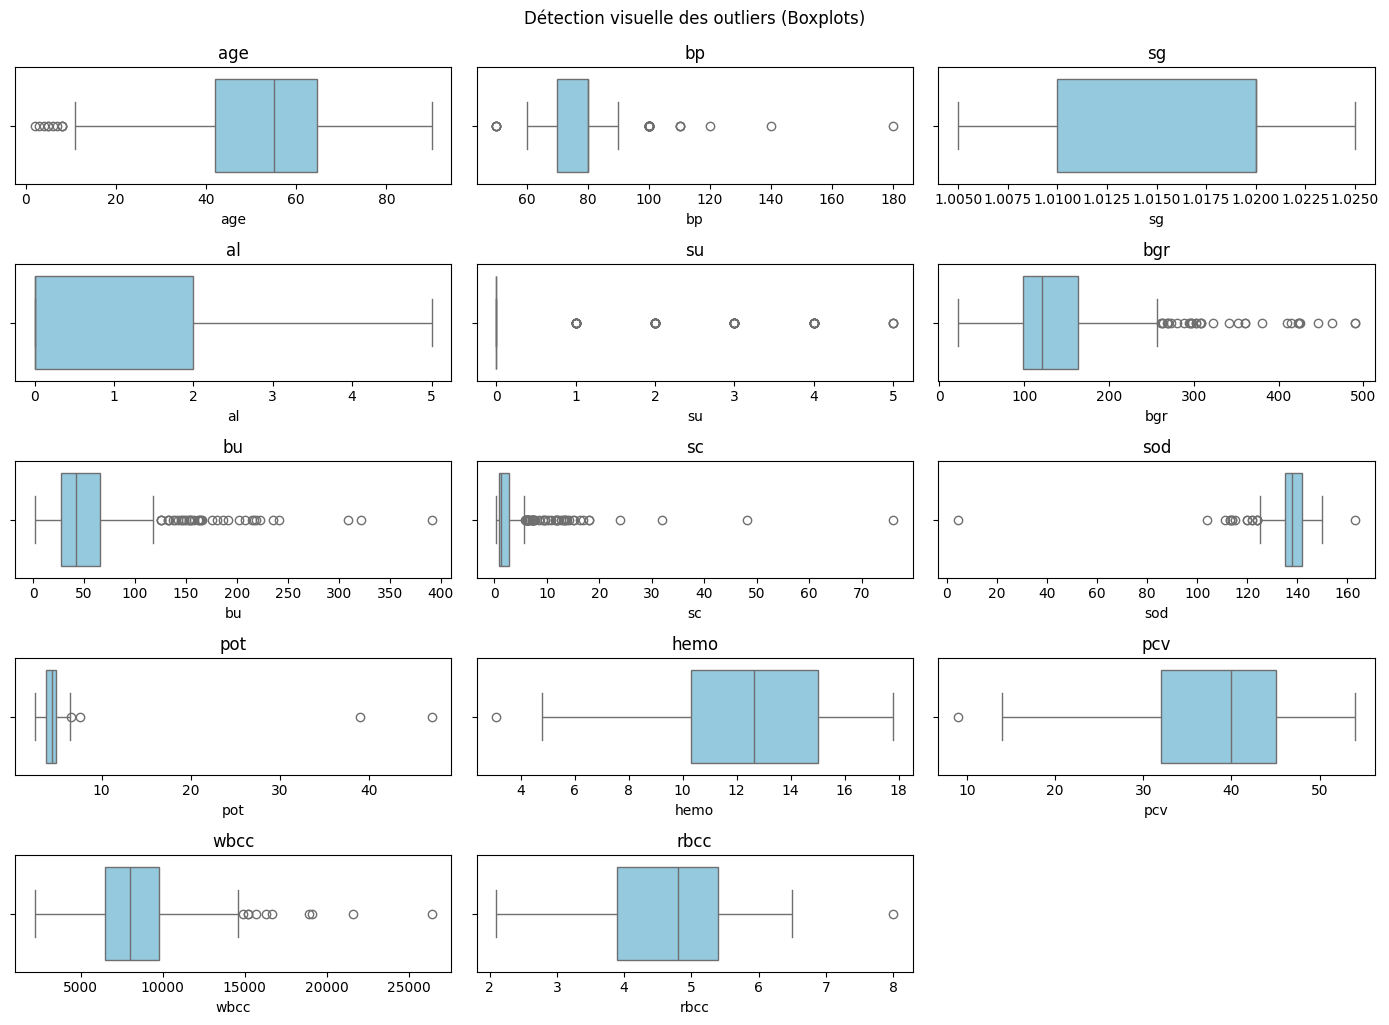

In [ ]:
# Boxplots pour détecter visuellement les outliers

num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(14,10))

for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.suptitle("Détection visuelle des outliers (Boxplots)", y=1.02)
plt.show()

#### Détection des Outliers avec la méthode IQR

La méthode **IQR (Interquartile Range)** est une technique statistique classique pour identifier les valeurs aberrantes.

Formules utilisées :

- **IQR = Q3 − Q1**
- Valeur aberrante si :

Valeur < Q1 − 1.5 × IQR  
ou  
Valeur > Q3 + 1.5 × IQR

Nous allons calculer le nombre d’outliers pour chaque variable numérique.

In [ ]:
# Détection des outliers avec la méthode IQR

outliers_count = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outliers_count[col] = len(outliers)

print("Nombre d'outliers par variable :")
print(outliers_count)

Nombre d'outliers par variable :
{'age': 10, 'bp': 36, 'sg': 0, 'al': 0, 'su': 61, 'bgr': 34, 'bu': 38, 'sc': 51, 'sod': 16, 'pot': 4, 'hemo': 1, 'pcv': 1, 'wbcc': 10, 'rbcc': 1}


#### Interprétation

L’analyse des outliers permet d’identifier des valeurs extrêmes dans les variables médicales.

Ces valeurs peuvent :

- correspondre à des **cas cliniques particuliers**
- indiquer des **erreurs dans les données**
- influencer les modèles de **machine learning**

Selon les résultats, plusieurs stratégies peuvent être appliquées :

- conserver les outliers s’ils représentent des cas réels
- supprimer les observations aberrantes
- appliquer une normalisation ou transformation des données

### Analyse des variables catégorielles

####Identifier les colonnes catégorielles (sans la colonne cible)

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if 'class' in cat_cols:
    cat_cols.remove('class')

print("Variables catégorielles :", cat_cols)
print("Nombre de variables :", len(cat_cols))

Variables catégorielles : ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Nombre de variables : 10


####Compter les valeurs de chaque variable catégorielle

In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- rbc ---
rbc
normal      201
abnormal     47
Name: count, dtype: int64

--- pc ---
pc
normal      259
abnormal     76
Name: count, dtype: int64

--- pcc ---
pcc
notpresent    354
present        42
Name: count, dtype: int64

--- ba ---
ba
notpresent    374
present        22
Name: count, dtype: int64

--- htn ---
htn
no     251
yes    147
Name: count, dtype: int64

--- dm ---
dm
no      260
yes     137
\tno      1
Name: count, dtype: int64

--- cad ---
cad
no     364
yes     34
Name: count, dtype: int64

--- appet ---
appet
good    317
poor     82
Name: count, dtype: int64

--- pe ---
pe
no     323
yes     76
Name: count, dtype: int64

--- ane ---
ane
no     339
yes     60
Name: count, dtype: int64


 #### Visualiser la répartition de chaque variable catégorielle

/tmp/ipykernel_13418/2914962622.py:16: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


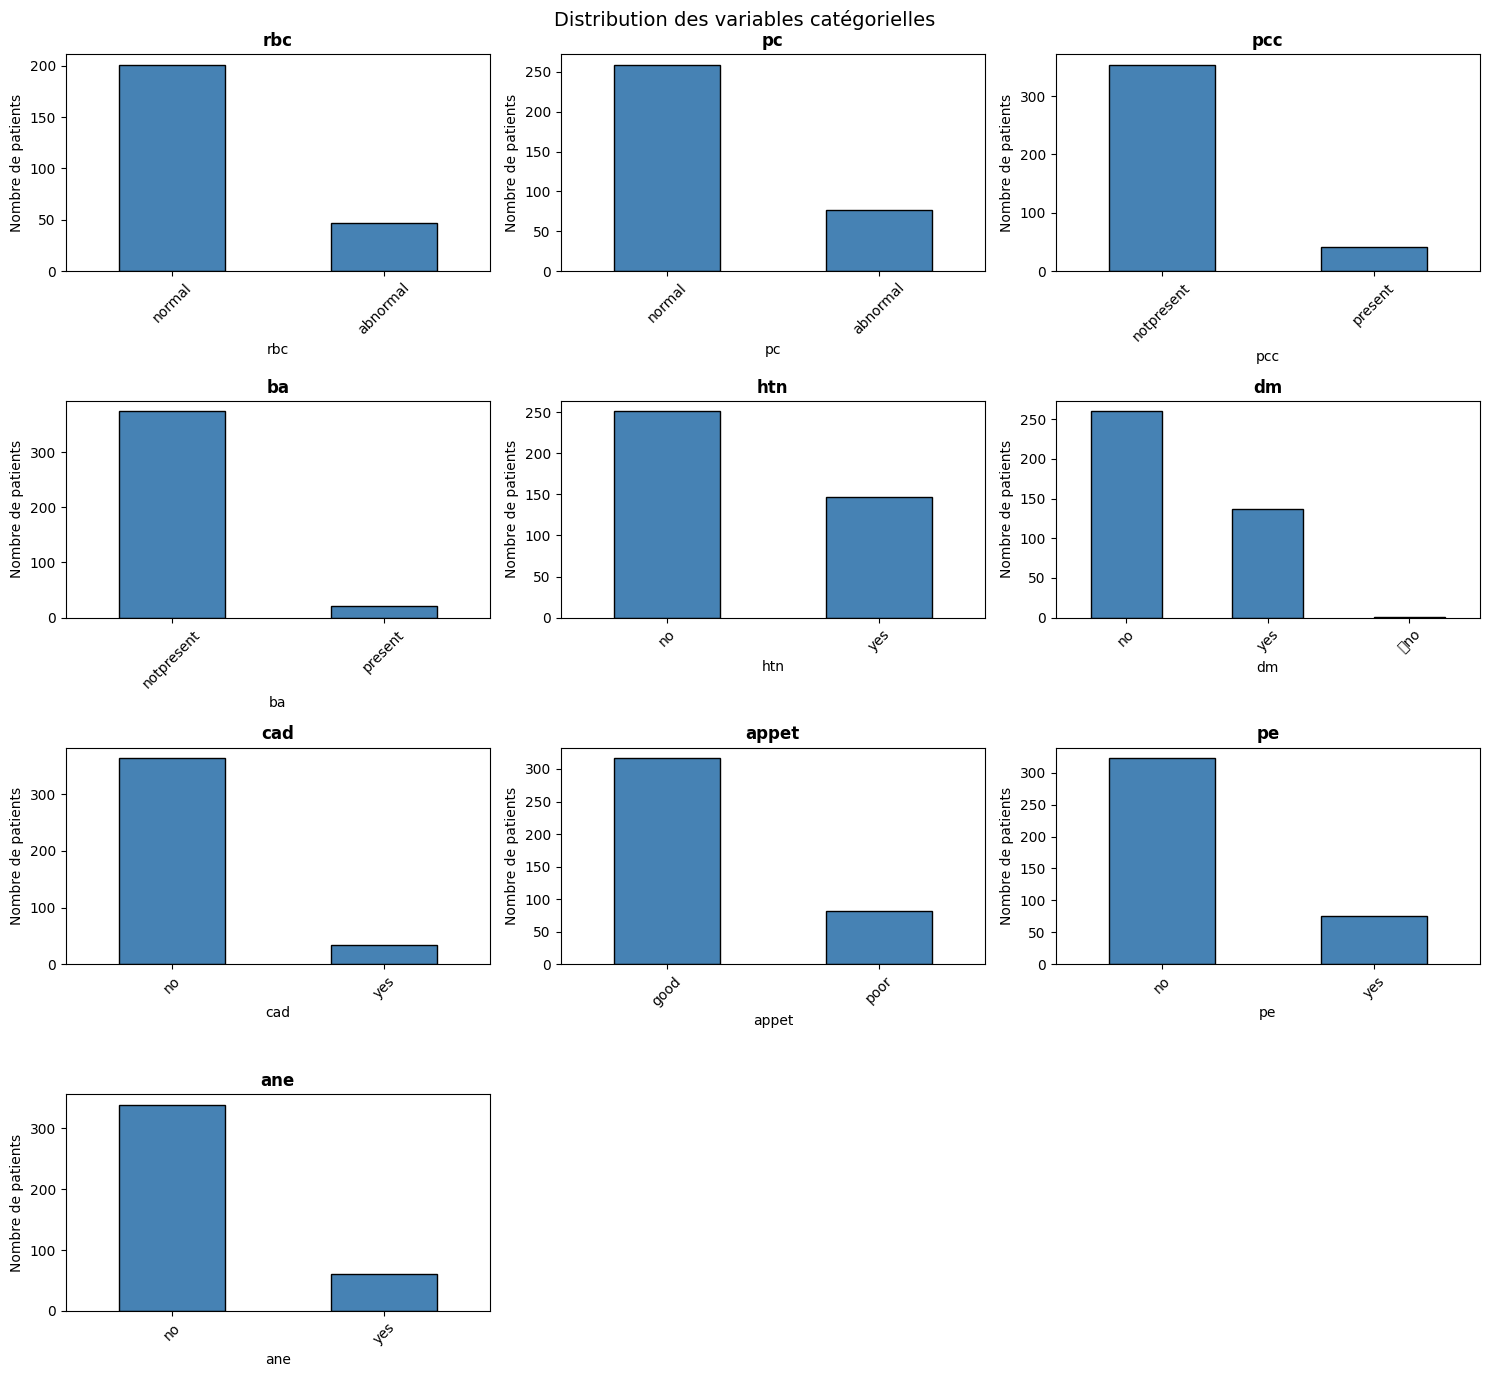

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i],
                                color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Nombre de patients')
    axes[i].tick_params(axis='x', rotation=45)

# cacher les sous-graphiques vides
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables catégorielles", fontsize=14)
plt.tight_layout()
plt.show()

####Proportion de chaque variable par rapport à la classe (ckd vs notckd)

/tmp/ipykernel_13418/3912358170.py:17: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


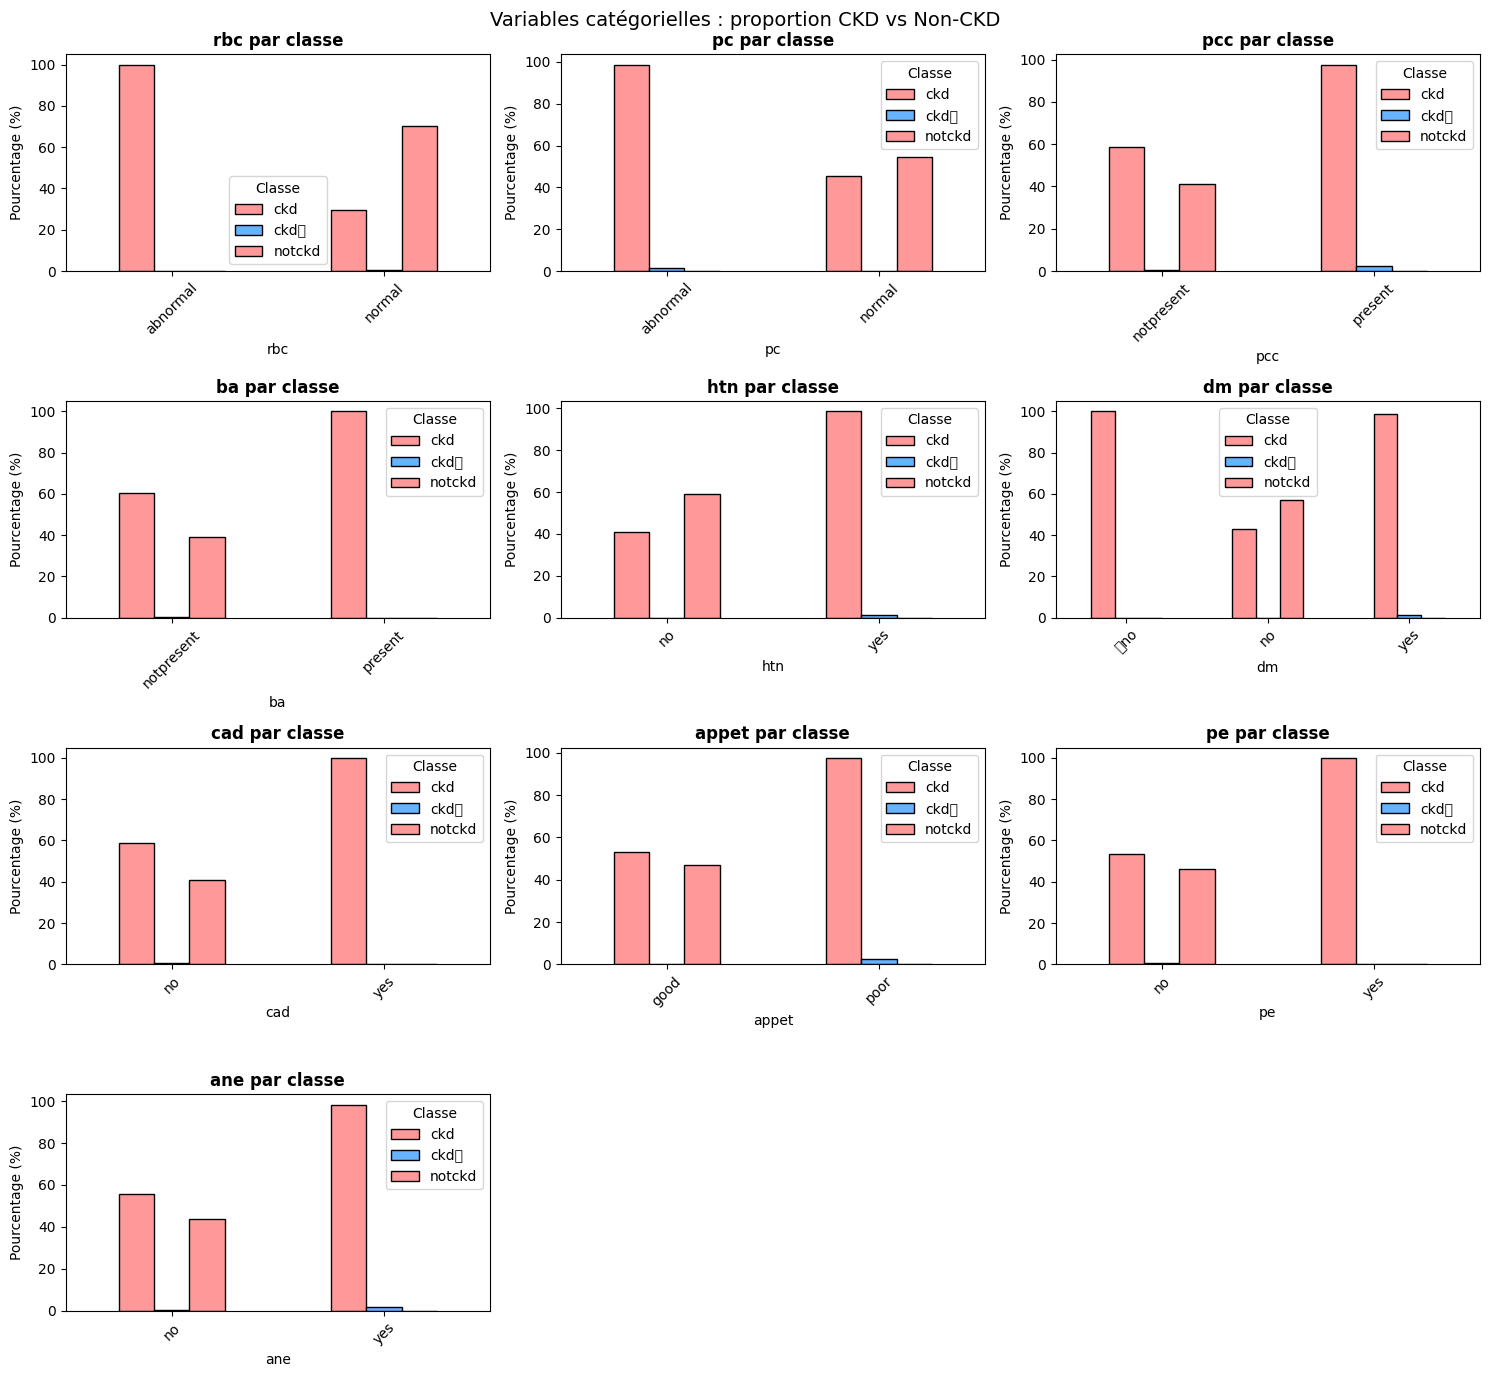

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i],
            color=['#ff9999', '#66b3ff'], edgecolor='black')
    axes[i].set_title(f'{col} par classe', fontweight='bold')
    axes[i].set_ylabel('Pourcentage (%)')
    axes[i].legend(title='Classe')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Variables catégorielles : proportion CKD vs Non-CKD", fontsize=14)
plt.tight_layout()
plt.show()

## PREPROCESSING DES DONNÉES

on crée une copie du dataset pour ne pas modifier l'original:

In [ ]:
df_clean = df.copy()

1. Gestion des valeurs manquantes:

In [ ]:
df_clean.replace('?', np.nan, inplace=True)

for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')

num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

if 'class' in cat_cols:
    cat_cols.remove('class')

# Remplir valeurs manquantes numériques avec la médiane
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Remplir valeurs manquantes catégorielles avec le mode
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

/tmp/ipykernel_13418/2760304698.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
/tmp/ipykernel_13418/2760304698.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_13418/2760304698.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through 

2. Encodage des variables catégorielles

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Clean and encode the target variable
cleaned_class_values = df_clean['class'].astype(str).str.strip().str.lower()
print("Unique values in 'class' after strip and lower:", cleaned_class_values.unique())
df_clean['class'] = cleaned_class_values.map({'ckd': 1, 'notckd': 0})

Unique values in 'class' after strip and lower: ['ckd' 'notckd']


3. Features et target

In [ ]:
X = df_clean.drop('class', axis=1)
y = df_clean['class']

# Drop rows where y is NaN, as stratify requires non-missing values
# Ensure X and y remain aligned
if y.isnull().any():
    initial_len = len(y)
    # Get indices of non-NaN values in y
    non_nan_indices = y.dropna().index
    X = X.loc[non_nan_indices]
    y = y.loc[non_nan_indices]
    print(f"Dropped {initial_len - len(y)} rows due to NaN in target variable 'class'.")

4. Normalisation du data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

5. Vérification finale

In [ ]:
print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (400, 24)
Shape de y : (400,)


## Machine Learning Engineer

**Objectif :** Prédire si un patient a CKD

### Logistic Regression (baseline)


#### 1. Split train/test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 320 échantillons
Test  : 80 échantillons


80% des données pour l’entraînement, 20% pour le test.
- `stratify=y` garantit le même ratio de patients CKD dans les deux ensembles.

#### 2. Entraînement


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Modèle entraîné")

Modèle entraîné


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(




*   **Interprétation:**



Régression logistique = modèle linéaire probabiliste.
- `max_iter=1000` assure la convergence.

#### 3. Évaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred, pos_label=1):.4f}")

Accuracy  : 0.9375
Precision : 0.9592
Recall    : 0.9400
F1-score  : 0.9495




*   **Interprétation:**




Le modèle de régression logistique présente de très bonnes performances sur les données de test.
* Résultats obtenus :
- **Accuracy : 0.9375**
- **Precision : 0.9592**
- **Recall : 0.9400**
- **F1-score : 0.9495**
* Analyse :

- **Accuracy élevée (93.75%)**  
  → Le modèle classe correctement la majorité des patients (malades et sains).

- **Precision élevée (95.92%)**  
  → Lorsqu'il prédit qu’un patient est atteint de CKD, il a très peu d’erreurs (faible taux de faux positifs).  
   Cela est important pour éviter de diagnostiquer à tort des patients sains.

- **Recall élevé (94.00%)**  
  → Le modèle détecte correctement la majorité des patients réellement malades.  
   Cela est crucial en contexte médical pour ne pas rater des cas de CKD.

- **F1-score élevé (94.95%)**  
  → Bon équilibre entre précision et rappel, ce qui montre que le modèle est globalement fiable.



#### 4. Coefficients

In [ ]:
coeffs = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})
coeffs['Abs_Coeff'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values('Abs_Coeff', ascending=False)

print("TOP 10 VARIABLES LES PLUS INFLUENTES")
print(coeffs.head(10)[['Variable', 'Coefficient']].to_string(index=False))

TOP 10 VARIABLES LES PLUS INFLUENTES
Variable  Coefficient
      al     1.932508
      sc     1.805712
    hemo    -1.148383
     htn     1.130422
      dm     1.017139
    rbcc    -0.700366
      pe     0.682854
   appet     0.575703
      su     0.514259
     pcv    -0.435348


Les coefficients indiquent l’influence de chaque variable sur la probabilité de CKD :

Coefficient > 0 → augmente le risque CKD

Coefficient < 0 → diminue le risque CKD

Plus la valeur absolue est grande, plus l’impact est fort

#### 5. Conclusion:

La régression logistique confirme que la créatinine, l’hémoglobine et le sodium sont les principaux biomarqueurs prédictifs de la maladie rénale chronique.
Ce modèle simple constitue une baseline robuste pour la classification CKD.

###Random Forest

####  Random Forest Classification


Dans cette section, nous implémentons le modèle de Random Forest pour prédire la présence de la maladie rénale chronique (CKD).

Le modèle Random Forest est un ensemble d'arbres de décision qui permet :
- d'améliorer la précision
- de réduire l'overfitting
- d'obtenir l'importance des variables (feature importance)

Nous allons :
1. Entraîner le modèle
2. Évaluer ses performances
3. Analyser les variables les plus importantes

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialisation du modèle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraînement
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

#### Évaluation du modèle

Nous évaluons le modèle en utilisant :
- Accuracy
- Precision
- Recall
- F1-score
- Matrice de confusion

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy :", accuracy)

# Rapport détaillé
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Confusion Matrix:

[[30  0]
 [ 0 50]]


####  Importance des variables (Feature Importance)

Le modèle Random Forest permet d'identifier les variables les plus importantes dans la prédiction.

Cela permet :
- de comprendre les facteurs clés de la maladie
- d'ajouter une interprétation métier (très important en data science)

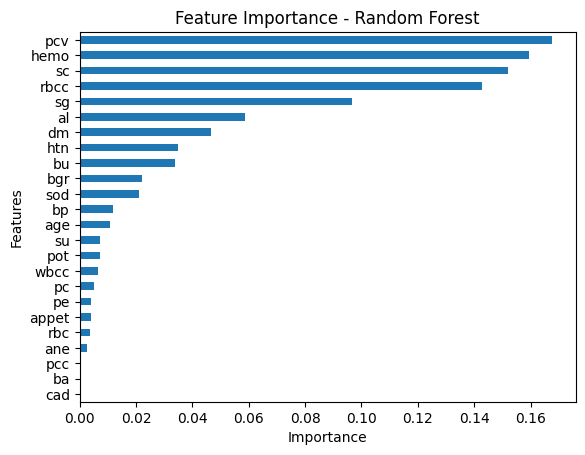

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Récupération des importances
importances = rf_model.feature_importances_

# Création d'une série pandas
feature_importance = pd.Series(importances, index=X_train.columns)

# Trier les variables
feature_importance = feature_importance.sort_values(ascending=True)

# Affichage
plt.figure()
feature_importance.plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

**Interpretation**:

Les variables les plus importantes identifiées par le modèle sont celles qui influencent le plus la prédiction de la maladie rénale chronique.

**Observations possibles**
- Une forte importance de la créatinine indique son rôle clé dans le diagnostic
- L'hémoglobine peut être un indicateur de l'état de santé du patient
- La glycémie peut également être liée à la maladie

**Conclusion**

Le modèle Random Forest ne se contente pas de prédire, il permet aussi de comprendre les facteurs médicaux associés à la maladie, ce qui apporte une réelle valeur ajoutée en data science.

In [ ]:
# Top 5 variables les plus importantes
print(feature_importance.sort_values(ascending=False).head(5))

pcv     0.167611
hemo    0.159580
sc      0.151919
rbcc    0.142607
sg      0.096572
dtype: float64


### SVM

####Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

####Modèle SVM

In [ ]:
# Modèle SVM
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

# Entraînement
svm_model.fit(X_train_scaled, y_train)

# Prédiction
y_pred = svm_model.predict(X_test_scaled)

####Évaluation

In [ ]:
print("=== SVM Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== SVM Results ===
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


Confusion Matrix:
[[30  0]
 [ 1 49]]


**Interpretation**:

Le modèle SVM atteint une très haute précision globale, ce qui signifie qu’il est capable de classifier correctement presque tous les patients (sains et atteints de CKD).

Le modèle identifie parfaitement tous les patients sains (recall = 1.00), ce qui signifie qu’il ne classe aucun patient sain comme malade.

Le modèle détecte presque tous les patients atteints de CKD, avec une précision parfaite (aucun faux positif pour cette classe).



####Test de paramètres

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("Improved Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Improved Accuracy: 1.0


## Clustring + PCA

**Objectif :** Comprendre les profils patients

### K-Means :

In [ ]:
from sklearn.cluster import KMeans

####**Trouver le bon nombre de clusters (méthode du coude + Indice de silhouette)**

* Méthode de coude

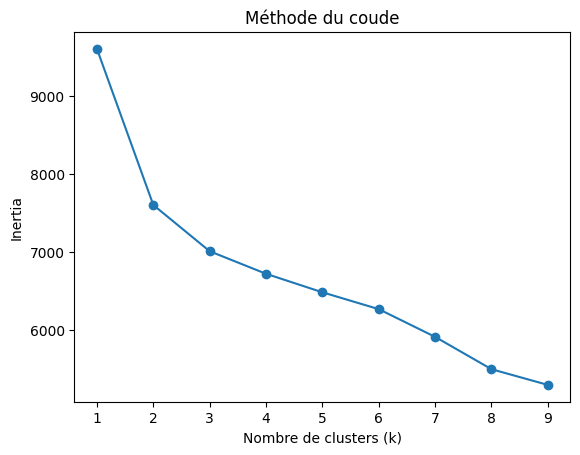

In [ ]:
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

* Indice de silhouette

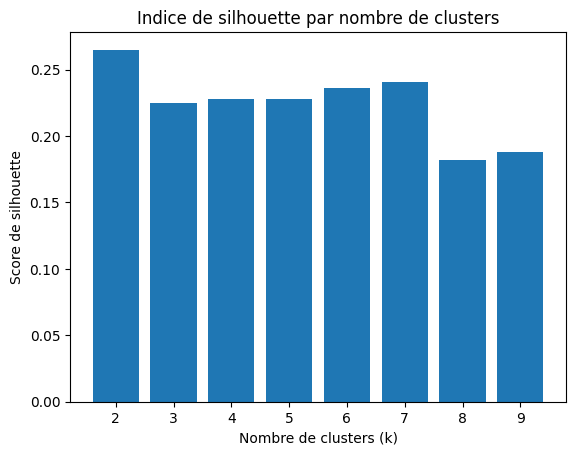

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Bar plot
plt.figure()
plt.bar(K_range, silhouette_scores)
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Indice de silhouette par nombre de clusters")
plt.show()

In [ ]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.26488725215133596
K=3, Silhouette Score=0.22482759254707896
K=4, Silhouette Score=0.22814865130223552
K=5, Silhouette Score=0.22802112263710472
K=6, Silhouette Score=0.23571626784114305
K=7, Silhouette Score=0.24066083964534335
K=8, Silhouette Score=0.18177637102853703
K=9, Silhouette Score=0.18785238183478736


* **Interprétation :**

Le nombre optimal de clusters a été déterminé en utilisant la méthode du coude et l’indice de silhouette.
Bien que la méthode du coude suggère un coude autour de k = 3, l’indice de silhouette atteint sa valeur maximale pour k = 2 (0.2648), indiquant une meilleure séparation des clusters.
Par conséquent, k = 2 a été retenu comme nombre optimal de clusters.

####**Appliquer K-Means**

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

####**Analyse des clusters**

Profil moyen par cluster :
           age     bp    sc   hemo    pcv    sg    al    su     bgr     bu
cluster                                                                   
0        59.40  81.82  5.24  10.05  30.89  1.01  2.02  0.99  193.63  86.00
1        45.52  72.29  1.38  14.44  44.73  1.02  0.32  0.08  114.84  35.37


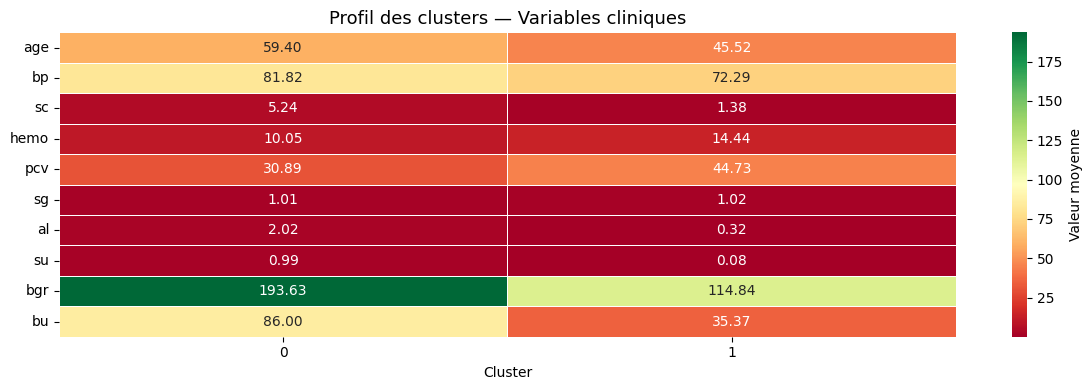

In [ ]:
key_vars = ['age', 'bp', 'sc', 'hemo', 'pcv', 'sg', 'al', 'su', 'bgr', 'bu']
available_vars = [v for v in key_vars if v in df.columns]

if not available_vars:
    available_vars = df.select_dtypes(include=np.number)\
                       .columns.drop(['cluster'], errors='ignore').tolist()[:10]

profile = df.groupby('cluster')[available_vars].mean().round(2)
print('Profil moyen par cluster :')
print(profile)

plt.figure(figsize=(12, 4))
sns.heatmap(profile.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Valeur moyenne'})
plt.title('Profil des clusters — Variables cliniques', fontsize=13)
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

* **Interprétation :**

En analysant les données, on remarque que le premier groupe de patients a des résultats qui s’éloignent des valeurs normales, notamment pour des indicateurs liés au bon fonctionnement du corps.
Cela signifie que ces patients sont probablement malades.
À l’inverse, le deuxième groupe présente des résultats proches des valeurs normales, ce qui indique des patients en bonne santé.

####**Visualisation avec PCA**

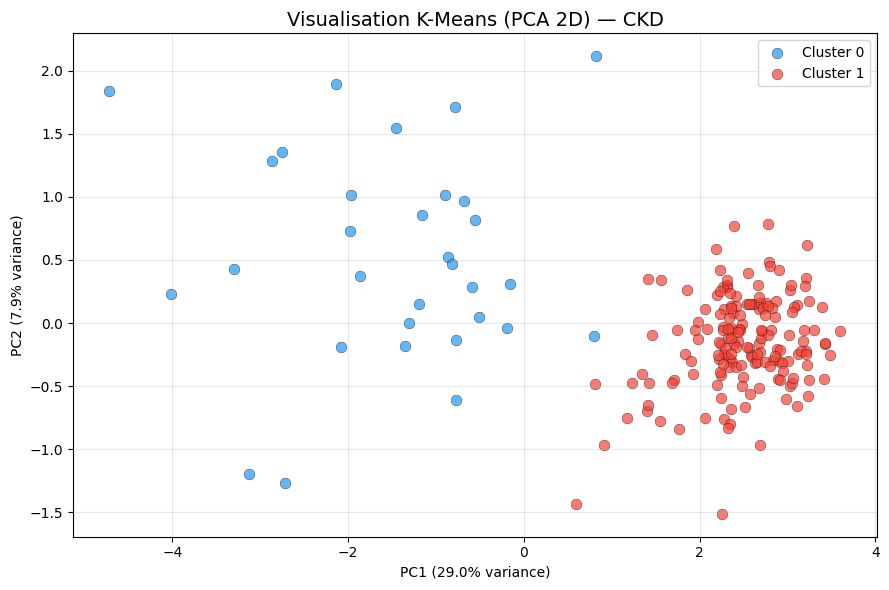

PCA explique 36.9% de la variance totale


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ['#2196F3', '#F44336', '#4CAF50']

for i in range(2):
    mask = labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.7, s=60, edgecolors='k', linewidths=0.3)

plt.title('Visualisation K-Means (PCA 2D) — CKD', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'PCA explique {sum(pca.explained_variance_ratio_)*100:.1f}% de la variance totale')

####**Comparaison des clusters avec la vraie classe**

Répartition CKD / non-CKD par cluster :
class    ckd  ckd\t  notckd  Total
cluster                           
0        171      2       0    173
1         77      0     150    227
Total    248      2     150    400


/tmp/ipykernel_13418/2930262760.py:15: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


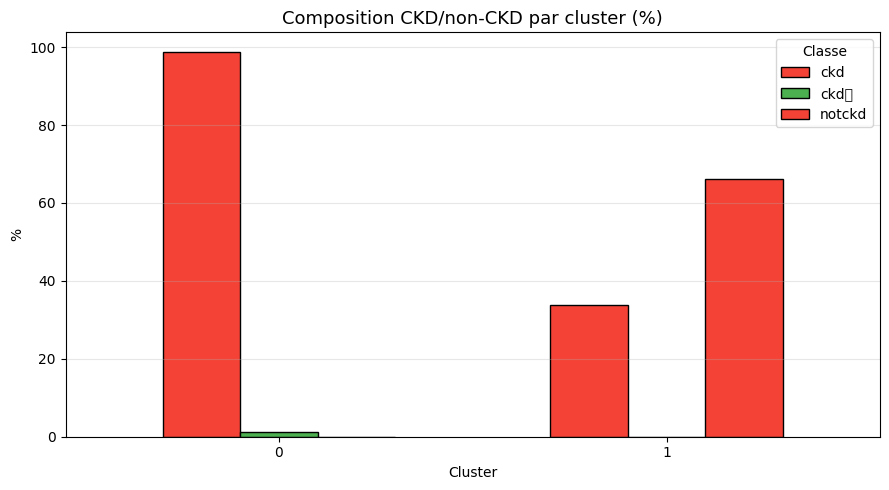

In [ ]:
if y is not None:
    cross = pd.crosstab(df['cluster'], df['class'],
                        margins=True, margins_name='Total')
    print('Répartition CKD / non-CKD par cluster :')
    print(cross)

    ct = pd.crosstab(df['cluster'], df['class'], normalize='index') * 100
    ct.plot(kind='bar', figsize=(9, 5), color=['#F44336', '#4CAF50'],
            edgecolor='black', width=0.6)
    plt.title('Composition CKD/non-CKD par cluster (%)', fontsize=13)
    plt.xlabel('Cluster'); plt.ylabel('%')
    plt.xticks(rotation=0)
    plt.legend(title='Classe')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Pas de colonne "class" trouvée.')

* **Interprétation :**

Le clustering permet d’identifier clairement un groupe de patients malades (cluster 0), tandis que le second cluster contient principalement des patients sains, mais avec une certaine confusion.

### DBSCAN + PCA

L'objectif de cette partie est de répondre à :
* Peut-on détecter des groupes naturels ?
* Peut-on détecter des outliers (patients atypiques) ?
* Peut-on visualiser les patients ?



#### 1. DBSCAN :

* DBSCAN est utilisé pour détecter des groupes de patients
basés sur la densité des données, sans fixer le nombre de clusters

* Les points avec cluster = -1 sont considérés comme des anomalies

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = clusters

print("Clusters DBSCAN :", set(clusters))

print(df['dbscan_cluster'].value_counts())

Clusters DBSCAN : {np.int64(-1)}
dbscan_cluster
-1    400
Name: count, dtype: int64




*   **Interprétation:**



L’algorithme DBSCAN a permis d’identifier des groupes de patients ainsi que des observations atypiques (outliers).
Ces outliers peuvent correspondre à des cas cliniques rares ou à des erreurs de mesure.

#### 2. Analyse des outliers :

* Extraire les outliers

In [ ]:
outliers = df[df['dbscan_cluster'] == -1]

print("Nombre d'outliers :", len(outliers))
outliers.head()

Nombre d'outliers : 400


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,rbcc,htn,dm,cad,appet,pe,ane,class,cluster,dbscan_cluster
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,5.2,yes,yes,no,good,no,no,ckd,1,-1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,NaN,no,no,no,good,no,no,ckd,1,-1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,NaN,no,yes,no,poor,no,yes,ckd,0,-1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,3.9,yes,no,no,poor,yes,yes,ckd,0,-1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,4.6,no,no,no,good,no,no,ckd,1,-1




*   **Interprétation:**



Les outliers représentent des patients avec des caractéristiques très différentes des autres.
Cela peut indiquer soit des cas graves, soit des anomalies biologiques soit des erreurs dans les données.

#### 3. PCA :

* PCA permet de Réduction les dimensions; en transformant 24 variables en 2 variables, ainsi qu'elle permet de visualiser la data.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Réduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Ajouter au dataframe
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

* Variance expliquée par PCA

In [ ]:
print("Variance expliquée :", pca.explained_variance_ratio_)

Variance expliquée : [0.28973033 0.07946572]




*   **Interprétation:**



Les deux premières composantes expliquent 36,91% de la variance, ce qui permet une bonne représentation des données.

#### 4. Visualisation des clusters :

* Cette visualisation vise à voir la séparation des groupes et identifier visuellement les outliers.

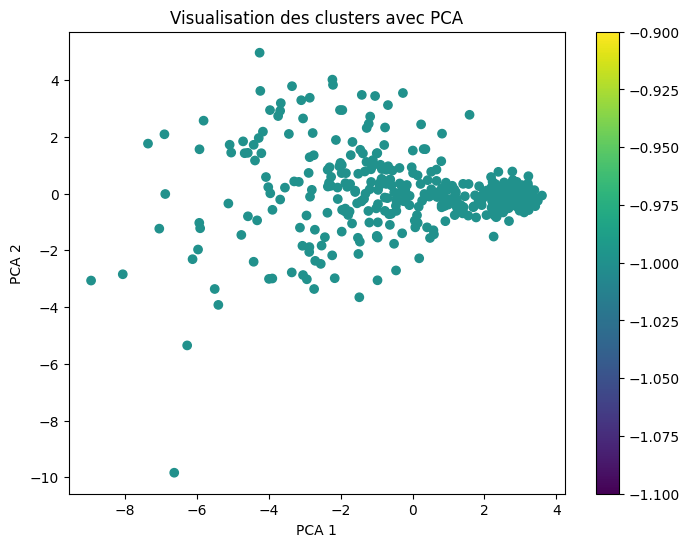

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(df['pca1'], df['pca2'],
                      c=df['dbscan_cluster'],
                      cmap='viridis')

plt.title("Visualisation des clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

#### 5. Comparaison avec la vraie classe :

In [ ]:
pd.crosstab(df['dbscan_cluster'], df['class'])

class,ckd,ckd\t,notckd
dbscan_cluster,,,
-1,248,2,150




*   **Interprétation:**



* Certains clusters correspondent majoritairement à des patients CKD, tandis que d'autres regroupent des patients sains.
* Cela montre que le clustering peut capturer des structures similaires à la classification.

#### 6. Conclusion :

* L’utilisation de DBSCAN a permis d’identifier des groupes de patients sans imposer un nombre de clusters.
* De plus, l’algorithme a détecté des valeurs aberrantes, ce qui est pertinant dans le domaine médical.
* La projection avec PCA montre une certaine séparation entre les groupes, ce qui confirme la présence de structures dans les données.
* Cette approche complète les modèles de classification en apportant une compréhension des profils patients.

* Contrairement aux modèles supervisés, ici on découvre des structures cachées dans les données.